In [15]:
import pandas as pd
df = pd.read_csv("Raw_data/anonymized_clinical.csv")

Exploring the Dataset:

In [16]:
# Explore the dataset
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  20000 non-null  object 
 1   TIME_FROM_TX_TO_ASSESSMENT  20000 non-null  object 
 2   ANONYM_ASSESSMENT_DATE      20000 non-null  object 
 3   BP_SYSTOLIC_mmHG            19321 non-null  float64
 4   BP_DIASTOLIC_mmHg           19319 non-null  float64
 5   TEMPERATUR_DEG              6356 non-null   float64
 6   PULSE_PER_MIN               18734 non-null  float64
 7   URINE_VOL_L                 13600 non-null  float64
 8   REC_WT_KG                   19764 non-null  float64
dtypes: float64(6), object(3)
memory usage: 1.4+ MB


,BP_SYSTOLIC_mmHG,BP_DIASTOLIC_mmHg,TEMPERATUR_DEG,PULSE_PER_MIN,URINE_VOL_L,REC_WT_KG
count,19321.000000,19319.000000,6356.000000,18734.000000,13600.000000,19764.000000
mean,134.451478,82.425488,35.998932,74.072328,2310.857868,72.340434
std,17.421327,11.537038,0.431339,12.486655,658.561112,15.521993
min,75.000000,10.000000,34.000000,36.000000,0.000000,5.000000
25%,123.000000,75.000000,35.900000,65.000000,1900.000000,60.200000
50%,133.000000,82.000000,36.000000,72.000000,2200.000000,71.000000
75%,144.000000,90.000000,36.100000,81.000000,2700.000000,82.000000
max,243.000000,183.000000,42.000000,183.000000,7500.000000,168.000000


In [17]:
# Check for missing values
missing_values = df.isnull().sum()
print(missing_values)

Patient_ID                        0
TIME_FROM_TX_TO_ASSESSMENT        0
ANONYM_ASSESSMENT_DATE            0
BP_SYSTOLIC_mmHG                679
BP_DIASTOLIC_mmHg               681
TEMPERATUR_DEG                13644
PULSE_PER_MIN                  1266
URINE_VOL_L                    6400
REC_WT_KG                       236
dtype: int64


In [18]:
# If cell is empty, convert it to NaN
df.replace('', pd.NA, inplace=True)

# Check the missing values for each Patient_ID
missing_values_by_patient = df.groupby('Patient_ID').apply(lambda x: x.isnull().sum())
print(missing_values_by_patient)

# Count the number of Patient_IDs with 0 missing values
complete_cases = missing_values_by_patient[missing_values_by_patient.sum(axis=1) == 0].shape[0]
print(f"Number of Patient_IDs with complete data: {complete_cases}")

# Count the number of Patient_IDs with full missing values for each column 
# (Column missing values for this patient = the number of rows of this patient_ID),
# and mention which column is it for each case
full_missing_cases = {}
for column in df.columns:
    full_missing = missing_values_by_patient[column] == df.groupby('Patient_ID').size()
    full_missing_cases[column] = full_missing.sum()
print("Number of Patient_IDs with full missing values for each column:")
for column, count in full_missing_cases.items():
    print(f"{column}: {count}")

            Patient_ID  TIME_FROM_TX_TO_ASSESSMENT  ANONYM_ASSESSMENT_DATE  \
Patient_ID                                                                   
P1000                0                           0                       0   
P1001                0                           0                       0   
P1002                0                           0                       0   
P1003                0                           0                       0   
P1004                0                           0                       0   
...                ...                         ...                     ...   
P1307                0                           0                       0   
P1308                0                           0                       0   
P1309                0                           0                       0   
P1310                0                           0                       0   
P1311                0                           0              

Cleaning:

In [19]:
# As there is a significant number of missing values, we will need to handle them 
# before proceeding with any analysis. We can consider options such as imputation 
# as dropping rows (complete case) could remove more than 30% of the dataset.
# I will impute using IterativeImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Remove the cleaned file
import os
if os.path.exists("Cleaned_data/cleaned_KGENE.csv"):
    os.remove("Cleaned_data/cleaned_KGENE.csv")


# Select only numeric columns for imputation, rounding the imputed values to 2 decimal places
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
imputer = IterativeImputer(random_state=0)
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])
df[numeric_cols] = df[numeric_cols].round(2)

# Checking the dataset again after imputation
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  20000 non-null  object 
 1   TIME_FROM_TX_TO_ASSESSMENT  20000 non-null  object 
 2   ANONYM_ASSESSMENT_DATE      20000 non-null  object 
 3   BP_SYSTOLIC_mmHG            20000 non-null  float64
 4   BP_DIASTOLIC_mmHg           20000 non-null  float64
 5   TEMPERATUR_DEG              20000 non-null  float64
 6   PULSE_PER_MIN               20000 non-null  float64
 7   URINE_VOL_L                 20000 non-null  float64
 8   REC_WT_KG                   20000 non-null  float64
dtypes: float64(6), object(3)
memory usage: 1.4+ MB
None


In [20]:
# Save the cleaned dataset to a new CSV file, by creating a new folder called "Cleaned_data" in the current directory
import os
os.makedirs("Cleaned_data", exist_ok=True)
df.to_csv("Cleaned_data/cleaned_KGENE.csv", index=False)

In [21]:
# Summarizing the data per patient
patient_summary = df.groupby('Patient_ID').agg({
    'BP_SYSTOLIC_mmHG': ['mean', 'std'],
    'BP_DIASTOLIC_mmHg': ['mean', 'std'],
    'TEMPERATUR_DEG': ['mean', 'std'],
    'PULSE_PER_MIN': ['mean', 'std'],
    'URINE_VOL_L': ['mean', 'std'],
    'REC_WT_KG': ['mean', 'std']
}).reset_index()
print(patient_summary)

    Patient_ID BP_SYSTOLIC_mmHG            BP_DIASTOLIC_mmHg             \
                           mean        std              mean        std   
0        P1000       118.758636  16.482338         84.338864  10.731735   
1        P1001       144.229535  17.944425         73.954884   8.547396   
2        P1002       126.687500   9.540921         86.750000   8.947998   
3        P1003       126.452727  11.204301         75.484318   6.787968   
4        P1004       131.677262  14.502133         86.556071   8.793062   
..         ...              ...        ...               ...        ...   
307      P1307       134.315816  14.973662         77.949796  12.388483   
308      P1308       105.176154  15.975243         65.941538   7.232641   
309      P1309       128.652000  12.901074         89.117400   7.976957   
310      P1310       125.614953  13.484370         84.542804  10.017095   
311      P1311       147.835882  10.205258         88.153235   5.924131   

    TEMPERATUR_DEG      

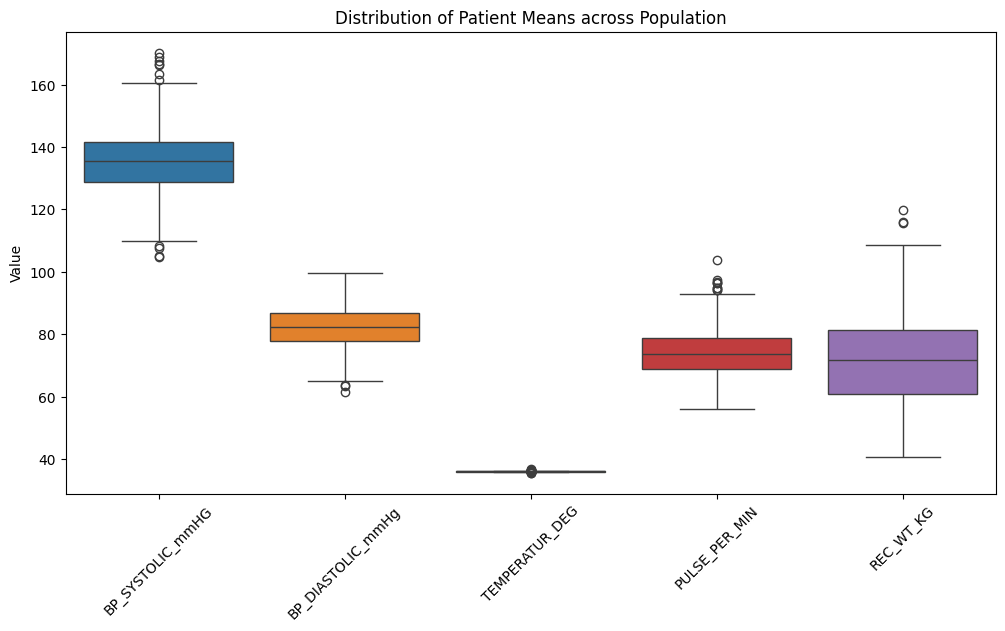

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Transpose the patient summary for easier plotting
df_plot = patient_summary.T

# Boxplot of Means to see the spread across the population
vitals = ['BP_SYSTOLIC_mmHG', 'BP_DIASTOLIC_mmHg', 'TEMPERATUR_DEG','PULSE_PER_MIN', 'REC_WT_KG']
plt.figure(figsize=(12, 6))
sns.boxplot(data=patient_summary[vitals].xs('mean', axis=1, level=1))
plt.title('Distribution of Patient Means across Population')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.show()

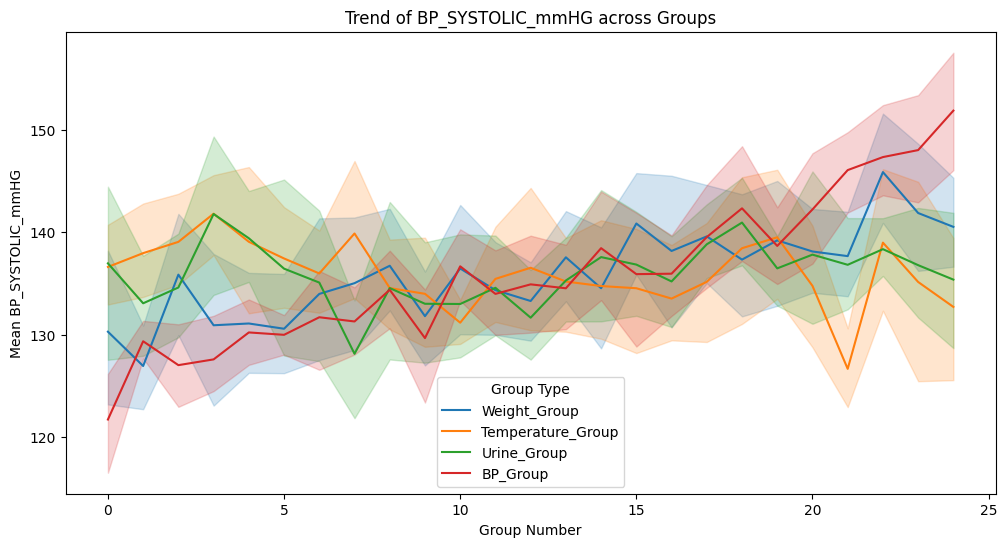

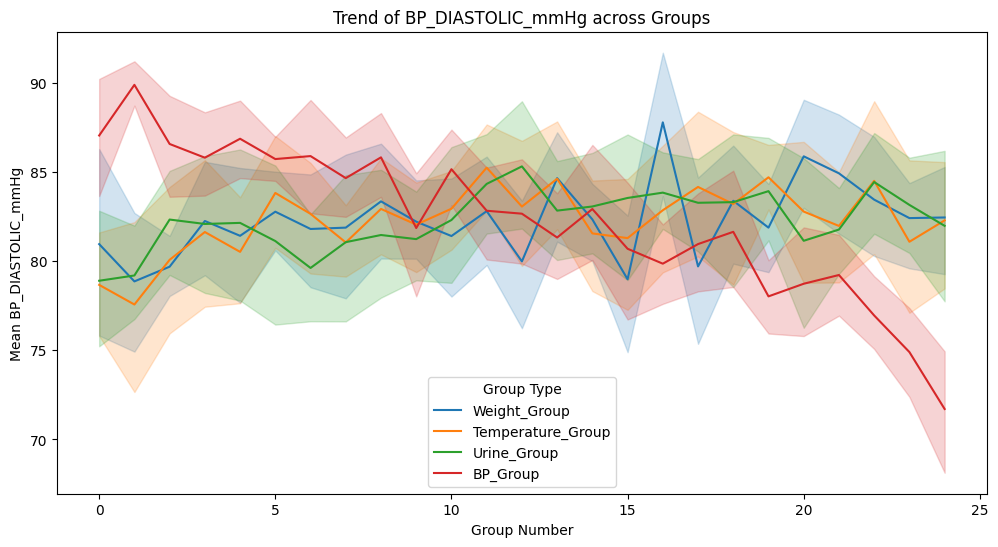

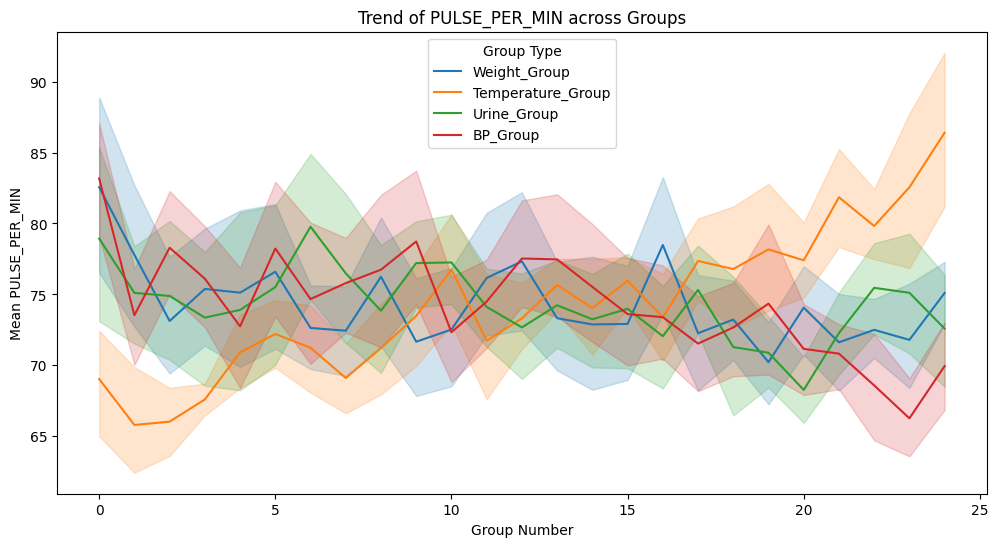

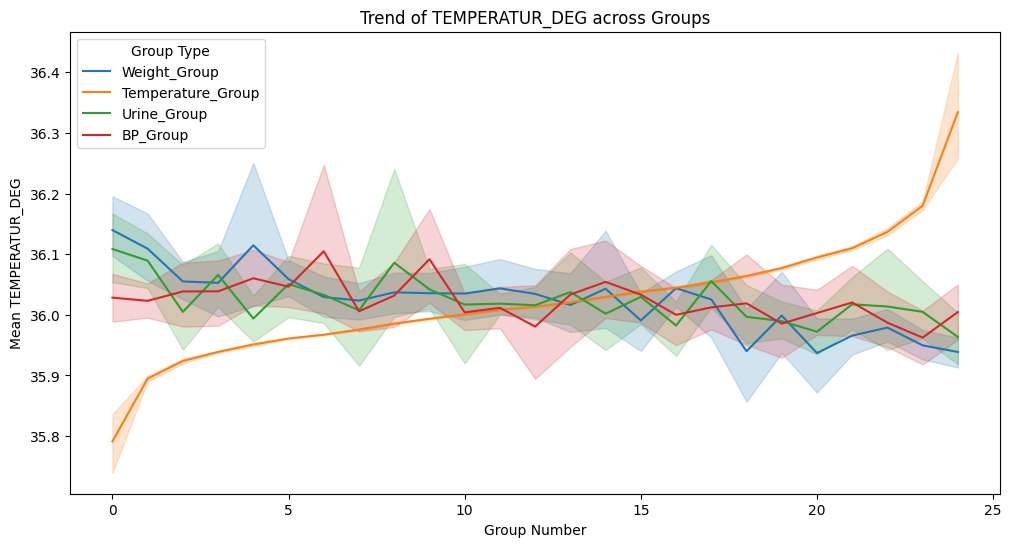

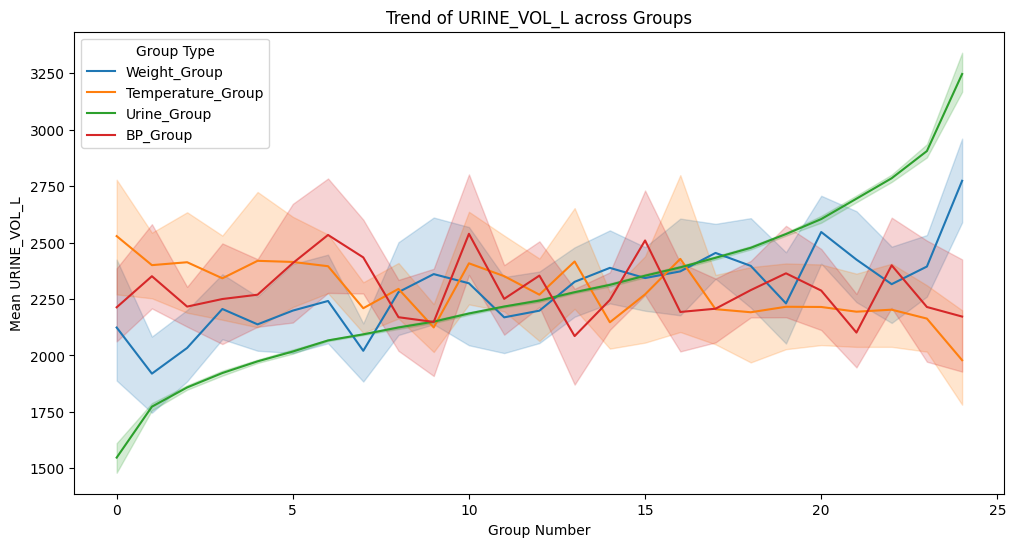

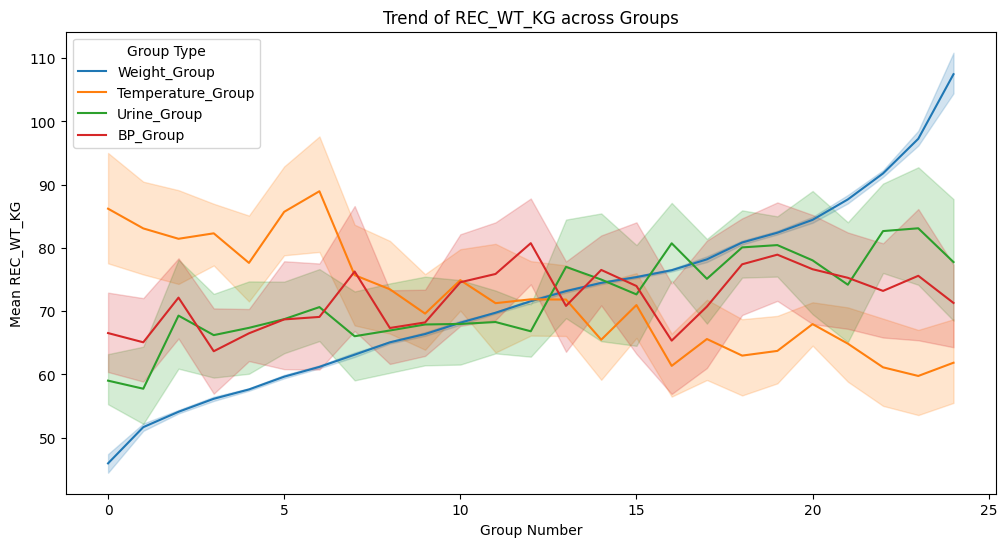

In [24]:
# Visualize the clinical trends of weight, blood pressure, and urine volume 
# Categorize the patients based on their mean weight, blood pressure, urine volume into 25 groups
patient_summary['Weight_Group'] = pd.qcut(patient_summary[('REC_WT_KG', 'mean')], q=25, labels=False)
patient_summary['Urine_Group'] = pd.qcut(patient_summary[('URINE_VOL_L', 'mean')], q=25, labels=False)
patient_summary['Temperature_Group'] = pd.qcut(patient_summary[('TEMPERATUR_DEG', 'mean')], q=25, labels=False)

# Categorize the patients based on their mean blood pressure into 10 groups considering 
# both systolic and diastolic and merge them in the same group
patient_summary['BP_Group'] = pd.qcut(patient_summary[('BP_SYSTOLIC_mmHG', 'mean')] / patient_summary[('BP_DIASTOLIC_mmHg', 'mean')], q=25, labels=False)

# Plot the trends for each vital sign in different plot using for loop, one for each vital sign, using the x as group number instead of patient id.
vital_signs = ['BP_SYSTOLIC_mmHG', 'BP_DIASTOLIC_mmHg', 'PULSE_PER_MIN', 'TEMPERATUR_DEG', 'URINE_VOL_L', 'REC_WT_KG']
groups = ['Weight_Group', 'Temperature_Group', 'Urine_Group', 'BP_Group']
for vital in vital_signs:
    plt.figure(figsize=(12, 6))
    for group in groups:
        sns.lineplot(x=group, y=(vital, 'mean'), data=patient_summary, label=group)
    plt.title(f'Trend of {vital} across Groups')
    plt.ylabel(f'Mean {vital}')
    plt.xlabel('Group Number')
    plt.legend(title='Group Type')
    plt.show()

Correlation between mean of each vital sign and group number for each grouping method:
BP_SYSTOLIC_mmHG:
  Weight_Group: 0.9713
  Temperature_Group: -0.5328
  Urine_Group: 0.4040
  BP_Group: 0.1771
BP_DIASTOLIC_mmHg:
  Weight_Group: 0.9713
  Temperature_Group: -0.5328
  Urine_Group: 0.4040
  BP_Group: 0.1771
PULSE_PER_MIN:
  Weight_Group: 0.9713
  Temperature_Group: -0.5328
  Urine_Group: 0.4040
  BP_Group: 0.1771
TEMPERATUR_DEG:
  Weight_Group: 0.9713
  Temperature_Group: -0.5328
  Urine_Group: 0.4040
  BP_Group: 0.1771
URINE_VOL_L:
  Weight_Group: 0.9713
  Temperature_Group: -0.5328
  Urine_Group: 0.4040
  BP_Group: 0.1771
REC_WT_KG:
  Weight_Group: 0.9713
  Temperature_Group: -0.5328
  Urine_Group: 0.4040
  BP_Group: 0.1771


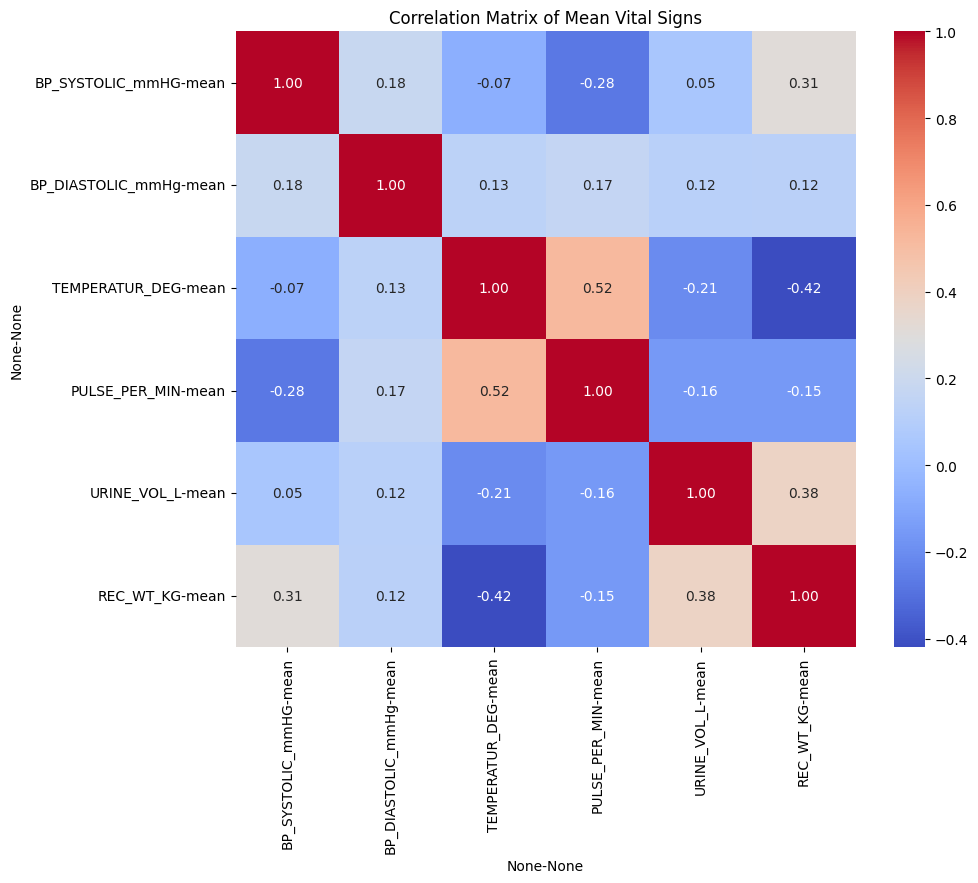

TypeError: unsupported format string passed to Series.__format__

In [35]:
# Calculate the correlation between the mean of each vital sign and the group number for each grouping method
correlations = {}
for vital in vital_signs:
    correlations[vital] = {}
    for group in groups:
        corr = patient_summary[('REC_WT_KG', 'mean')].corr(patient_summary[group])
        correlations[vital][group] = corr
print("Correlation between mean of each vital sign and group number for each grouping method:")
for vital, group_corr in correlations.items():
    print(f"{vital}:")
    for group, corr in group_corr.items():
        print(f"  {group}: {corr:.4f}")

# Visualize the correlation using a heatmap shows the correlation between the mean 
# of each vital sign and each vital sign, not the mean of the whole group.
correlation_matrix = patient_summary[[('BP_SYSTOLIC_mmHG', 'mean'), ('BP_DIASTOLIC_mmHg', 'mean'), 
                                      ('TEMPERATUR_DEG', 'mean'), ('PULSE_PER_MIN', 'mean'), 
                                      ('URINE_VOL_L', 'mean'), ('REC_WT_KG', 'mean')]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Mean Vital Signs')
plt.show()

# Print the highest correlation for each vital sign and the corresponding vital sign
for vital in vital_signs:
    corr_with_vital = correlation_matrix[vital]
    highest_corr = corr_with_vital.drop(vital).max()
    corresponding_vital = corr_with_vital.drop(vital).idxmax()
    print(f"The highest correlation for {vital} is with {corresponding_vital[0]} with a correlation of {highest_corr:.4f}")


In [46]:
time_vitals = ['BP_SYSTOLIC_mmHG', 'BP_DIASTOLIC_mmHg', 'PULSE_PER_MIN', 'URINE_VOL_L', 'REC_WT_KG']

# 1. Force Time to be numeric (This is the most likely cause of empty plots)
df['TIME_FROM_TX_TO_ASSESSMENT'] = pd.to_numeric(df['TIME_FROM_TX_TO_ASSESSMENT'], errors='coerce')

for vital in time_vitals:
    # 2. Create a clean temporary subset for this specific vital
    # This removes rows where EITHER Time or the Vital is missing
    temp_df = df[['TIME_FROM_TX_TO_ASSESSMENT', vital]].copy().dropna()
    temp_df = temp_df.sort_values('TIME_FROM_TX_TO_ASSESSMENT')

    if temp_df.empty:
        print(f"Skipping {vital}: No valid data found.")
        continue

    plt.figure(figsize=(10, 5))
    
    # 3. Calculate rolling average on the clean subset
    # Increased window to 100 to make the line smoother and easier to see
    temp_df['rolling_mean'] = temp_df[vital].rolling(window=100, center=True, min_periods=1).mean()
    
    # 4. Draw BLUE Line (Rolling Mean)
    sns.lineplot(x='TIME_FROM_TX_TO_ASSESSMENT', y='rolling_mean', data=temp_df, 
                 color='blue', linewidth=1.5, errorbar=None, label='Rolling Average')
    
    # 5. Draw RED Line (General Trend)
    sns.regplot(x='TIME_FROM_TX_TO_ASSESSMENT', y=vital, data=temp_df, 
                scatter=False, color='red', 
                line_kws={"linewidth": 2.5, "label": "General Trend"})
    
    plt.title(f'Clinical Trend Analysis: {vital}', fontsize=14)
    plt.ylabel(f'Value of {vital}')
    plt.xlabel('Days from Transplant')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()

Skipping BP_SYSTOLIC_mmHG: No valid data found.
Skipping BP_DIASTOLIC_mmHg: No valid data found.
Skipping PULSE_PER_MIN: No valid data found.
Skipping URINE_VOL_L: No valid data found.
Skipping REC_WT_KG: No valid data found.


In [ ]:
# Also, let me know whether patients show stabilization of vitals in 
# the first months after transplant. If yes, what's the general trend?


# Do you find some correlations between Clinical Variables

# Which vital sign can be a key indicator of graft function?
